# Time series 13: AR(1) only (first-order autoregression per channel, no clustering)

Fit a **first-order autoregression (AR(1))** per channel: \(y_{t,j} = \phi_j\, y_{t-1,j} + c_j\). No clustering — each channel has its own \((\phi_j, c_j)\) fitted on training data. Compare to **naive** (persistence) and display results.

- **Model**: One AR(1) per channel, OLS on that channel’s training series.
- **Split**: 60% train, 10% val, 30% test (same as other notebooks).
- **Evaluation**: MAPE, RMSE, MAE; MAE/MASE per step vs naive.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

_root = Path.cwd().resolve()
if _root.name == "time_series":
    _root = _root.parent
DATA_PATH = _root / "data" / "transformed" / "transformed_data.parquet"
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix(".csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Transform data not found at {DATA_PATH}. Run task transform first.")

df = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == ".parquet" else pd.read_csv(DATA_PATH)
df = df.sort_values(["date", "hour"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")

freq_bands = sorted([c for c in df.columns if c not in ("date", "hour", "datetime")])
N = len(freq_bands)
Z = df[freq_bands].values.astype(np.float64)
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
T_total = Z.shape[0]

print(f"Loaded {len(df)} rows. Channels: {N}, Shape: (T={T_total}, N={N})")

Loaded 9192 rows. Channels: 70, Shape: (T=9192, N=70)


## Train / validation / test split and optional low-pass filter

In [2]:
train_ratio, val_ratio, test_ratio = 0.6, 0.1, 0.3
n_train = int(T_total * train_ratio)
n_val = int(T_total * val_ratio)
n_test = T_total - n_train - n_val

USE_LOWPASS = True
CUTOFF = 0.5
FILTER_ORDER = 3

def lowpass_per_channel(Z_mat, cutoff=0.5, order=3):
    from scipy.signal import butter, filtfilt
    normal_cutoff = min(float(cutoff), 0.99)
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    out = np.zeros_like(Z_mat)
    for j in range(Z_mat.shape[1]):
        out[:, j] = filtfilt(b, a, Z_mat[:, j])
    return out

if USE_LOWPASS:
    Z_full = lowpass_per_channel(Z, cutoff=CUTOFF, order=FILTER_ORDER)
    print(f"Applied low-pass filter (cutoff={CUTOFF}, order={FILTER_ORDER}).")
else:
    Z_full = Z.copy()

Z_train = Z_full[:n_train]
Z_val = Z_full[n_train : n_train + n_val]
Z_test = Z_full[n_train + n_val :]
test_start = n_train + n_val
print(f"Train: {n_train}, Val: {n_val}, Test: {n_test}")

Applied low-pass filter (cutoff=0.5, order=3).
Train: 5515, Val: 919, Test: 2758


## AR(1) per channel (no clustering)

For each channel \(j\), fit \(y_t = \phi_j\, y_{t-1} + c_j\) on training data by OLS.

In [3]:
ar1_phi = np.zeros(N)
ar1_c = np.zeros(N)
for j in range(N):
    y = Z_train[1:, j]
    x = Z_train[:-1, j]
    phi, c_val = np.polyfit(x, y, 1)
    ar1_phi[j] = float(phi)
    ar1_c[j] = float(c_val)
print(f"Fitted AR(1) for {N} channels.")

Fitted AR(1) for 70 channels.


## Test: rolling prediction

In [4]:
pred_test = np.zeros((n_test, N), dtype=np.float64)
for t in range(n_test):
    prev_idx = test_start + t - 1 if t > 0 else test_start - 1
    for j in range(N):
        pred_test[t, j] = ar1_phi[j] * Z_full[prev_idx, j] + ar1_c[j]

mape = np.mean(np.abs((Z_test - pred_test) / (np.abs(Z_test) + 1e-8))) * 100
rmse = np.sqrt(np.mean((Z_test - pred_test) ** 2))
mae = np.mean(np.abs(Z_test - pred_test))

print("AR(1) per channel (test set):")
print(f"  MAPE = {mape:.4f}%")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAE  = {mae:.4f}")

AR(1) per channel (test set):
  MAPE = 15.3450%
  RMSE = 4.6017
  MAE  = 2.8692


## Naive baseline

In [5]:
pred_naive = np.zeros((n_test, N), dtype=np.float64)
for t in range(n_test):
    pred_naive[t] = Z_full[test_start + t - 1] if t > 0 else Z_full[test_start - 1]

mape_naive = np.mean(np.abs((Z_test - pred_naive) / (np.abs(Z_test) + 1e-8))) * 100
rmse_naive = np.sqrt(np.mean((Z_test - pred_naive) ** 2))
mae_naive = np.mean(np.abs(Z_test - pred_naive))

print("Naive (last value repeated):")
print(f"  MAPE = {mape_naive:.4f}%, RMSE = {rmse_naive:.4f}, MAE = {mae_naive:.4f}")

Naive (last value repeated):
  MAPE = 13.0105%, RMSE = 4.5277, MAE = 2.7672


## Comparison and plots: AR(1) vs Naive

Comparison: AR(1) vs Naive
  MAPE: AR(1) = 15.3450%,  Naive = 13.0105%
  RMSE: AR(1) = 4.6017,  Naive = 4.5277
  MAE:  AR(1) = 2.8692,  Naive = 2.7672


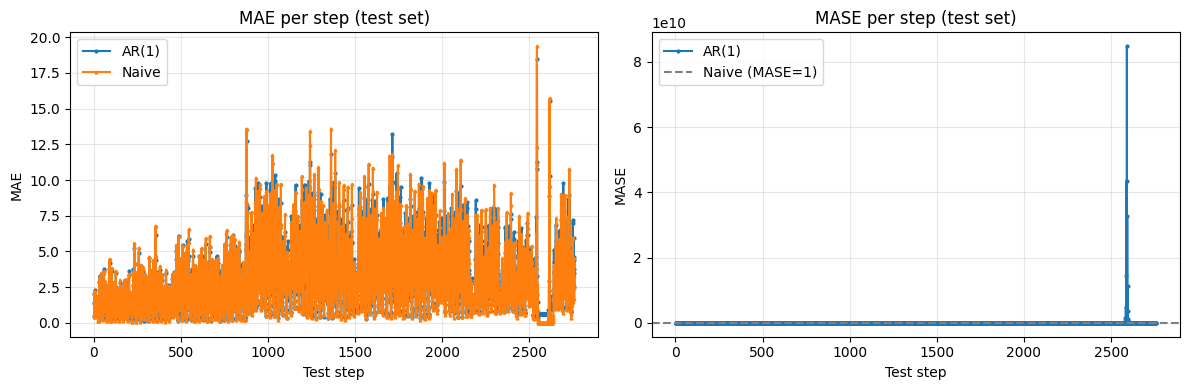

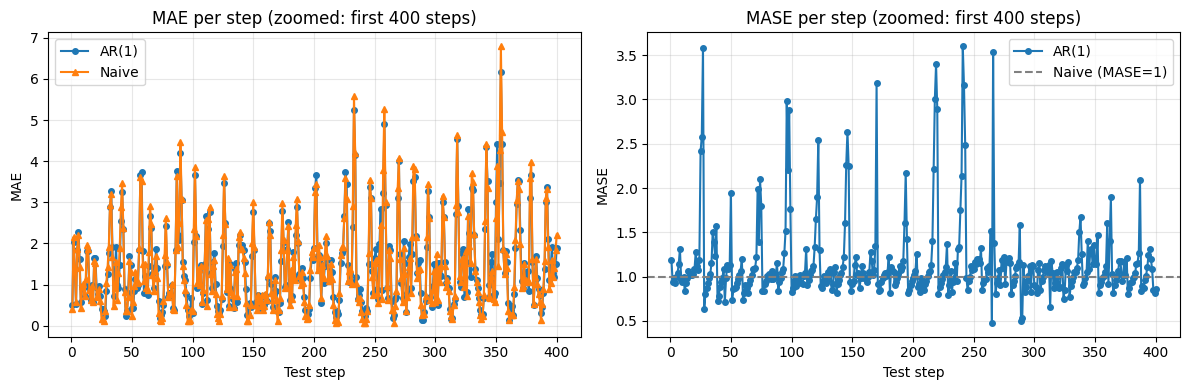

In [6]:
print("Comparison: AR(1) vs Naive")
print(f"  MAPE: AR(1) = {mape:.4f}%,  Naive = {mape_naive:.4f}%")
print(f"  RMSE: AR(1) = {rmse:.4f},  Naive = {rmse_naive:.4f}")
print(f"  MAE:  AR(1) = {mae:.4f},  Naive = {mae_naive:.4f}")

import matplotlib.pyplot as plt
maes_ar1 = [float(np.mean(np.abs(Z_test[t] - pred_test[t]))) for t in range(n_test)]
maes_naive_d = [float(np.mean(np.abs(Z_test[t] - pred_naive[t]))) for t in range(n_test)]
mase_ar1 = [maes_ar1[t] / (maes_naive_d[t] + 1e-12) for t in range(n_test)]
steps = list(range(1, n_test + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(steps, maes_ar1, "o-", label="AR(1)", markersize=2)
ax1.plot(steps, maes_naive_d, "^-", label="Naive", markersize=2)
ax1.set_xlabel("Test step")
ax1.set_ylabel("MAE")
ax1.set_title("MAE per step (test set)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(steps, mase_ar1, "o-", label="AR(1)", markersize=2)
ax2.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
ax2.set_xlabel("Test step")
ax2.set_ylabel("MASE")
ax2.set_title("MASE per step (test set)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

zoom_steps = min(400, n_test)
steps_zoom = steps[:zoom_steps]
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
ax3.plot(steps_zoom, maes_ar1[:zoom_steps], "o-", label="AR(1)", markersize=4)
ax3.plot(steps_zoom, maes_naive_d[:zoom_steps], "^-", label="Naive", markersize=4)
ax3.set_xlabel("Test step")
ax3.set_ylabel("MAE")
ax3.set_title(f"MAE per step (zoomed: first {zoom_steps} steps)")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax4.plot(steps_zoom, mase_ar1[:zoom_steps], "o-", label="AR(1)", markersize=4)
ax4.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
ax4.set_xlabel("Test step")
ax4.set_ylabel("MASE")
ax4.set_title(f"MASE per step (zoomed: first {zoom_steps} steps)")
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()